# Feature Selection Pipeline

Select optimal features from engineered dataset for flight delay prediction.

**Process:**
1. Categorical encoding (target + one-hot)
2. Feature scaling (standardization)
3. Correlation analysis
4. Tree-based importance ranking
5. SelectKBest feature selection
6. Final validation and output

## 1. Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load engineered data
df = pd.read_csv(r'c:\Users\owner\jupyter stuff\EDA\df_engineered.csv')
print(f"Loaded engineered data: {df.shape}")

Loaded engineered data: (56136, 61)


## 2. Categorical Encoding

Convert categorical variables to numeric using appropriate encoding methods.

In [3]:
df_encoded = df.copy()

# Target-encode high-cardinality features (airline, destination, aircraft)
target_encode_cols = ['airline', 'destination', 'aircraft']

for col in target_encode_cols:
    target_mean = df_encoded.groupby(col)['is_delayed'].mean()
    df_encoded[f'{col}_encoded'] = df_encoded[col].map(target_mean)

# One-hot encode time_period
time_dummies = pd.get_dummies(df_encoded['time_period'], prefix='time_period', drop_first=True)
df_encoded = pd.concat([df_encoded, time_dummies], axis=1)

# Drop original categorical columns
drop_cols = target_encode_cols + ['time_period']
df_encoded = df_encoded.drop(columns=[c for c in drop_cols if c in df_encoded.columns], errors='ignore')

print(f"  - Target encoded: {target_encode_cols}")
print(f"  - One-hot encoded: time_period")
print(f"  - New shape: {df_encoded.shape}")

  - Target encoded: ['airline', 'destination', 'aircraft']
  - One-hot encoded: time_period
  - New shape: (56136, 63)


## 3. Feature Scaling

Standardize numeric features for better model performance.

In [4]:
df_scaled = df_encoded.copy()

# Identify numeric columns to scale
exclude_cols = ['id', 'date', 'scheduled_departure', 'actual_departure', 
                'flight_number', 'is_delayed', 'delay_minutes', 'date_str', 
                'scheduled_dep_str', 'actual_dep_str', 'scheduled_departure_dt', 
                'actual_departure_dt', 'day_of_week']

numeric_cols = df_scaled.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

# Fill NaN with 0 and scale
df_scaled[numeric_cols] = df_scaled[numeric_cols].fillna(0)
scaler = StandardScaler()
df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])

print(f"  - Mean of scaled features: {df_scaled[numeric_cols].mean().mean():.6f}")
print(f"  - Std of scaled features: {df_scaled[numeric_cols].std().mean():.6f}")

  - Mean of scaled features: -0.000000
  - Std of scaled features: 1.000009


## 4. Correlation Analysis

Identify features with weak correlation to target and remove them.

In [5]:
# Calculate correlations
drop_cols = ['id', 'date', 'scheduled_departure', 'actual_departure', 
             'flight_number', 'is_delayed', 'delay_minutes', 'date_str', 
             'scheduled_dep_str', 'actual_dep_str', 'scheduled_departure_dt', 
             'actual_departure_dt', 'day_of_week']

df_numeric = df_scaled.drop(columns=[c for c in drop_cols if c in df_scaled.columns], errors='ignore')
df_numeric = df_numeric.select_dtypes(include=[np.number])

correlations = df_numeric.corrwith(df_scaled['is_delayed']).sort_values(ascending=False)

print(f"\nTop 20 Features by Correlation with Target:")
print(correlations.head(20))

# Features with low correlation
low_corr_features = correlations[abs(correlations) < 0.05].index.tolist()
print(f"\nFeatures to Remove (|r| < 0.05): {len(low_corr_features)}")
print(f"  {low_corr_features[:10]}...")


Top 20 Features by Correlation with Target:
route_hour_delay_rate           0.370499
airline_hour_delay_rate         0.365743
route_delay_rate                0.208589
destination_encoded             0.208589
delay_ratio_prev_3_airline      0.202263
prev_aircraft_delayed           0.175305
airline_encoded                 0.156037
airline_delay_rate              0.156037
aircraft_encoded                0.135344
aircraft_delay_rate             0.135344
hour                            0.133333
is_evening_rush                 0.101343
flights_per_hour                0.072198
concurrent_departures           0.072198
unique_destinations_per_hour    0.072132
unique_airlines_per_hour        0.069339
queue_position                  0.064099
hour_cos                        0.060856
cloud_cover_mid                 0.046965
precipitation                   0.032640
dtype: float64

Features to Remove (|r| < 0.05): 22
  ['cloud_cover_mid', 'precipitation', 'wind_direction_10m', 'wind_gusts_10m', 'day

### Insight: Feature Correlations

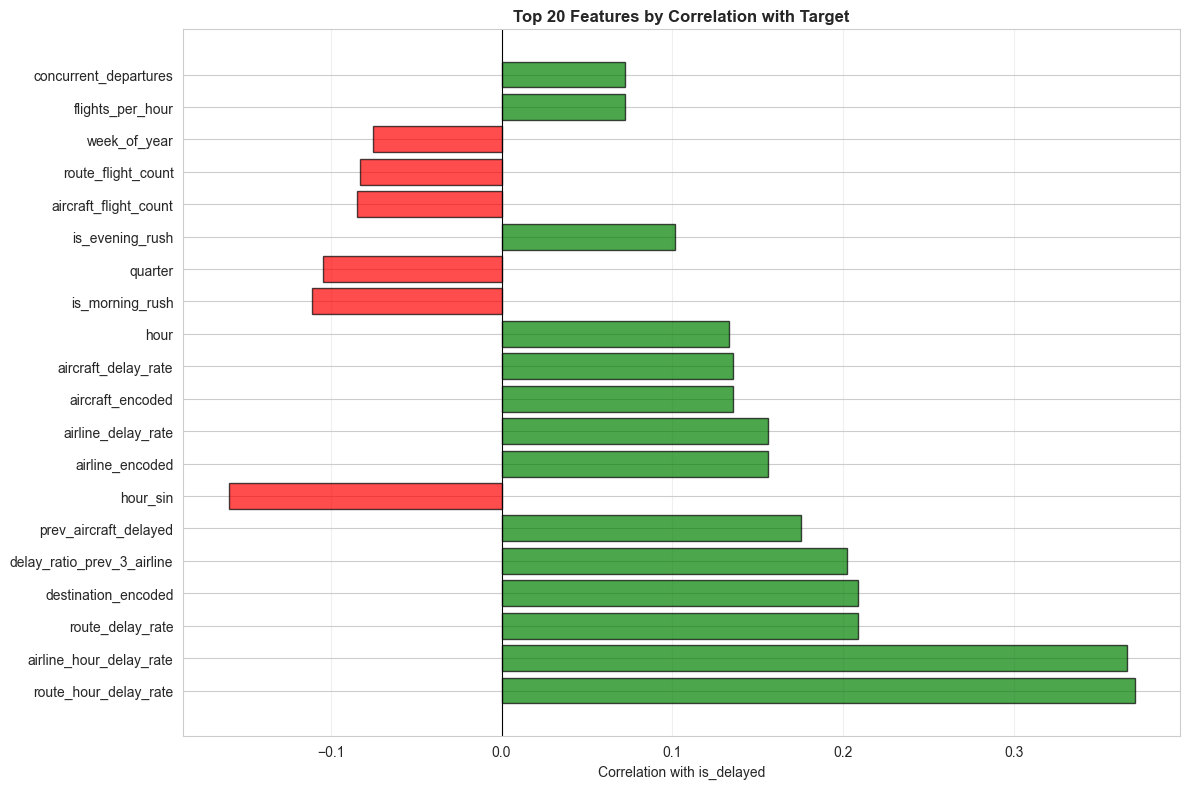


Key Insights:
  - Strongest predictor: route_hour_delay_rate (r=0.370)
  - Features with |r| > 0.2: 5
  - Features with |r| < 0.05: 22 (will be removed)


In [6]:
# Visualize correlations
fig, ax = plt.subplots(figsize=(12, 8))

# Top 20 by absolute correlation
top_corr = correlations.abs().nlargest(20)
colors = ['red' if x < 0 else 'green' for x in correlations[top_corr.index]]
ax.barh(range(len(top_corr)), correlations[top_corr.index].values, color=colors, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels(top_corr.index)
ax.set_xlabel('Correlation with is_delayed')
ax.set_title('Top 20 Features by Correlation with Target', fontweight='bold', fontsize=12)
ax.axvline(0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nKey Insights:")
print(f"  - Strongest predictor: {correlations.idxmax()} (r={correlations.max():.3f})")
print(f"  - Features with |r| > 0.2: {len(correlations[abs(correlations) > 0.2])}")
print(f"  - Features with |r| < 0.05: {len(low_corr_features)} (will be removed)")

## 5. Tree-Based Feature Importance

Use Random Forest to rank features and validate correlations.

In [7]:
# Prepare data for Random Forest
X = df_numeric.copy()
y = df_scaled['is_delayed']

print(f"Training Random Forest on {X.shape[1]} features...")
rf = RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
rf.fit(X, y)

# Feature importance
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 20 Features by Tree Importance:")
print(importances.head(20)[['feature', 'importance']].to_string(index=False))

Training Random Forest on 47 features...

Top 20 Features by Tree Importance:
                     feature  importance
       route_hour_delay_rate    0.208517
     airline_hour_delay_rate    0.148235
     prev_delay_same_airline    0.047443
            route_delay_rate    0.041545
    avg_delay_prev_5_airline    0.040730
       prev_aircraft_delayed    0.038529
         destination_encoded    0.037634
                    hour_sin    0.031751
      avg_delay_prev_5_route    0.030419
                        hour    0.029838
                week_of_year    0.024359
  delay_ratio_prev_3_airline    0.021611
             airline_encoded    0.019825
          airline_delay_rate    0.018284
                day_of_month    0.018157
                       month    0.016833
unique_destinations_per_hour    0.013176
              queue_position    0.012891
       concurrent_departures    0.011949
            flights_per_hour    0.011744


### Insight: Feature Importance Ranking

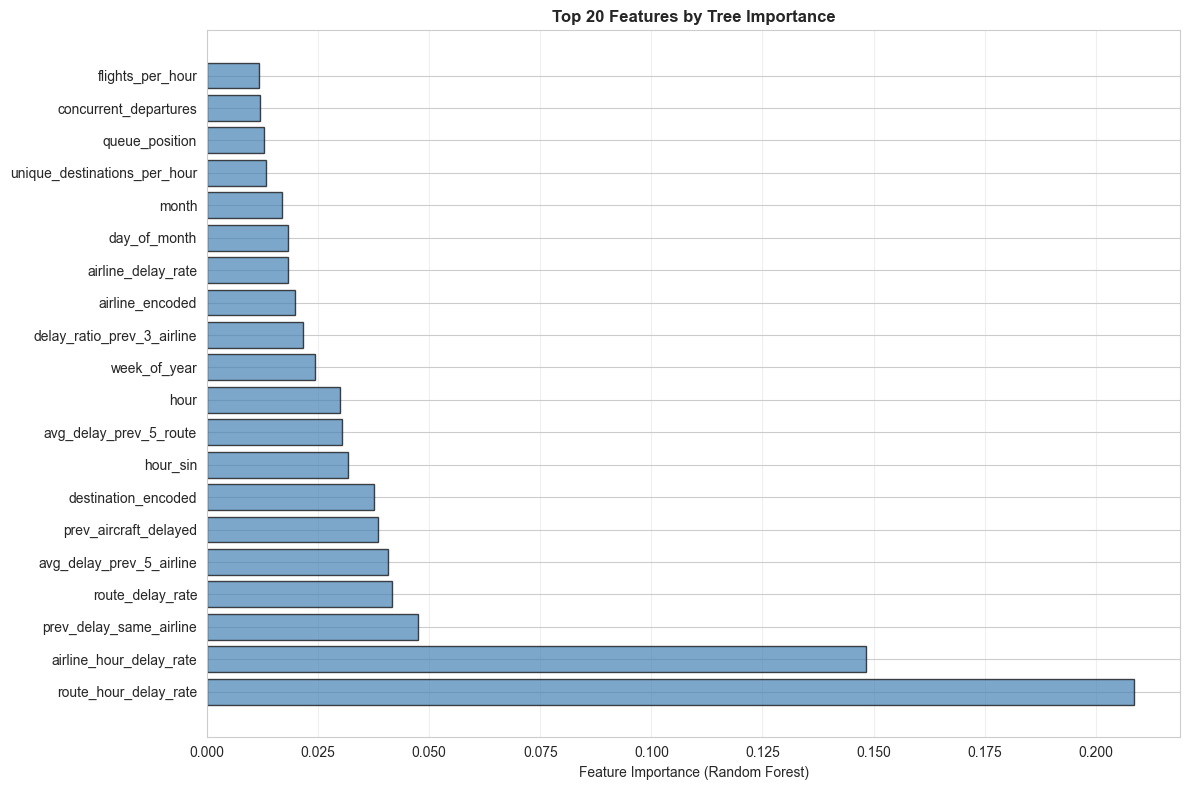


Key Insights:
  - Top feature: route_hour_delay_rate (0.209)
  - Top 5 features account for: 48.6% of importance
  - Interaction features dominate top rankings


In [8]:
# Visualize feature importance
fig, ax = plt.subplots(figsize=(12, 8))

top_n = 20
top_features = importances.head(top_n)
ax.barh(range(len(top_features)), top_features['importance'].values, 
        color='steelblue', alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'].values)
ax.set_xlabel('Feature Importance (Random Forest)')
ax.set_title(f'Top {top_n} Features by Tree Importance', fontweight='bold', fontsize=12)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nKey Insights:")
print(f"  - Top feature: {importances.iloc[0]['feature']} ({importances.iloc[0]['importance']:.3f})")
print(f"  - Top 5 features account for: {importances.head(5)['importance'].sum()*100:.1f}% of importance")
print(f"  - Interaction features dominate top rankings")

## 6. SelectKBest Feature Selection

Use univariate statistical tests to select top features.

In [9]:
# SelectKBest
k = 25
selector = SelectKBest(score_func=f_classif, k=k)
selector.fit(X, y)

# Get selected features
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask].tolist()

# Feature scores
feature_scores = pd.DataFrame({
    'feature': X.columns,
    'score': selector.scores_
}).sort_values('score', ascending=False)

print(f"Selected {k} features using SelectKBest:")
print(feature_scores.head(k)[['feature', 'score']].to_string(index=False))

Selected 25 features using SelectKBest:
                     feature       score
       route_hour_delay_rate 8931.526795
     airline_hour_delay_rate 8668.520827
            route_delay_rate 2553.453354
         destination_encoded 2553.453354
  delay_ratio_prev_3_airline 2394.413187
       prev_aircraft_delayed 1779.798812
                    hour_sin 1469.697056
             airline_encoded 1400.832863
          airline_delay_rate 1400.832863
         aircraft_delay_rate 1047.455877
            aircraft_encoded 1047.455877
                        hour 1015.999113
             is_morning_rush  695.176562
                     quarter  622.382733
             is_evening_rush  582.496383
       aircraft_flight_count  403.042665
          route_flight_count  386.844080
                week_of_year  320.873844
       concurrent_departures  294.131299
            flights_per_hour  294.131299
unique_destinations_per_hour  293.594478
    unique_airlines_per_hour  271.190148
              que

### Insight: Feature Selection Convergence

Do different selection methods agree on which features matter?

In [10]:
# Compare selection methods
top_corr_features = correlations.abs().nlargest(25).index.tolist()
top_rf_features = importances.head(25)['feature'].tolist()
top_kb_features = feature_scores.head(25)['feature'].tolist()

# Find agreement
agreement = set(top_corr_features) & set(top_rf_features) & set(top_kb_features)
print(f"Agreement across selection methods: {len(agreement)}/25 features")
print(f"\nTop 5 features selected by all methods:")
for i, feat in enumerate(list(agreement)[:5], 1):
    print(f"  {i}. {feat}")

Agreement across selection methods: 17/25 features

Top 5 features selected by all methods:
  1. prev_aircraft_delayed
  2. route_delay_rate
  3. queue_position
  4. week_of_year
  5. route_flight_count


## 7. Final Feature Set

Create final dataset with selected features.

In [11]:
# Create final dataset
keep_cols = ['id', 'is_delayed', 'delay_minutes', 'flight_number', 'airline', 'destination']
final_cols = keep_cols + selected_features
final_cols = [c for c in final_cols if c in df_encoded.columns]

df_final = df_encoded[final_cols].copy()

print(f"FINAL FEATURE SET")
print(f"\nFinal dataset shape: {df_final.shape}")
print(f"  - Rows: {df_final.shape[0]:,}")
print(f"  - Columns: {df_final.shape[1]}")
print(f"  - Features for modeling: {len(selected_features)}")
print(f"\nSelected Features ({len(selected_features)}):")
for i, feat in enumerate(selected_features, 1):
    importance = importances[importances['feature'] == feat]['importance'].values
    if len(importance) > 0:
        print(f"  {i:2d}. {feat:<35} (importance: {importance[0]:.4f})")
    else:
        print(f"  {i:2d}. {feat:<35}")

FINAL FEATURE SET

Final dataset shape: (56136, 29)
  - Rows: 56,136
  - Columns: 29
  - Features for modeling: 25

Selected Features (25):
   1. hour                                (importance: 0.0298)
   2. month                               (importance: 0.0168)
   3. quarter                             (importance: 0.0082)
   4. week_of_year                        (importance: 0.0244)
   5. is_morning_rush                     (importance: 0.0051)
   6. is_evening_rush                     (importance: 0.0016)
   7. hour_sin                            (importance: 0.0318)
   8. hour_cos                            (importance: 0.0076)
   9. flights_per_hour                    (importance: 0.0117)
  10. airline_delay_rate                  (importance: 0.0183)
  11. route_delay_rate                    (importance: 0.0415)
  12. route_flight_count                  (importance: 0.0116)
  13. aircraft_delay_rate                 (importance: 0.0102)
  14. aircraft_flight_count              

### Insight: Feature Set Summary

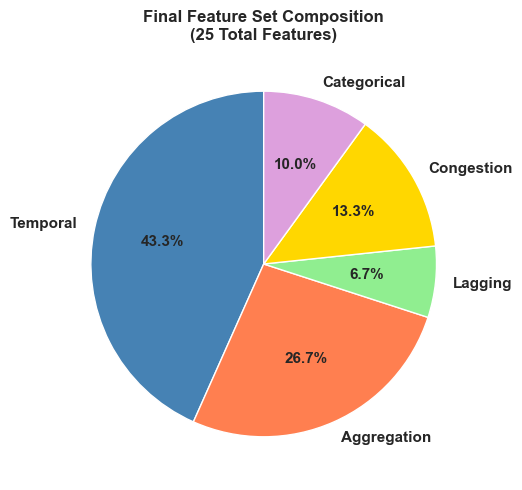


Feature Breakdown:
  - Temporal: 13 features
  - Aggregation: 8 features
  - Lagging: 2 features
  - Congestion: 4 features
  - Categorical: 3 features


In [15]:
# Categorize selected features
temporal_feats = [f for f in selected_features if any(x in f for x in ['hour', 'day', 'month', 'quarter', 'week', 'peak', 'rush', 'weekend', 'period'])]
agg_feats = [f for f in selected_features if any(x in f for x in ['delay_rate', 'flight_count', 'concurrent'])]
lagging_feats = [f for f in selected_features if any(x in f for x in ['prev', 'avg_delay', 'ratio'])]
congestion_feats = [f for f in selected_features if any(x in f for x in ['queue', 'concurrent', 'unique'])]
categorical_feats = [f for f in selected_features if any(x in f for x in ['encoded', 'time_period'])]

# Visualization
fig, ax = plt.subplots(figsize=(15, 5))

categories = {
    'Temporal': len(temporal_feats),
    'Aggregation': len(agg_feats),
    'Lagging': len(lagging_feats),
    'Congestion': len(congestion_feats),
    'Categorical': len(categorical_feats)
}

colors_map = ['steelblue', 'coral', 'lightgreen', 'gold', 'plum']
ax.pie(categories.values(), labels=categories.keys(), autopct='%.1f%%', 
       colors=colors_map, startangle=90, textprops={'fontsize': 11, 'weight': 'bold'})
ax.set_title('Final Feature Set Composition\n(25 Total Features)', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print(f"\nFeature Breakdown:")
print(f"  - Temporal: {len(temporal_feats)} features")
print(f"  - Aggregation: {len(agg_feats)} features")
print(f"  - Lagging: {len(lagging_feats)} features")
print(f"  - Congestion: {len(congestion_feats)} features")
print(f"  - Categorical: {len(categorical_feats)} features")

## 8. Save Results

In [13]:
import os

# Save final data
final_path = r'c:\Users\owner\jupyter stuff\EDA\df_final_features.csv'
df_final.to_csv(final_path, index=False)
print(f"✓ Final dataset saved: {final_path}")
print(f"  File size: {os.path.getsize(final_path) / 1024 / 1024:.1f} MB")

# Save feature metadata
metadata_path = r'c:\Users\owner\jupyter stuff\EDA\feature_metadata.csv'
feature_metadata = pd.DataFrame({
    'selected_features': selected_features,
    'feature_importance_rank': importances[importances['feature'].isin(selected_features)]['importance'].values
})
feature_metadata.to_csv(metadata_path, index=False)
print(f"✓ Feature metadata saved: {metadata_path}")

# Save encoding map
encoding_path = r'c:\Users\owner\jupyter stuff\EDA\encoding_map.txt'
with open(encoding_path, 'w') as f:
    f.write("Encoding Map\n")
    f.write("="*50 + "\n")
    f.write("Target Encoded (Mean Encoding):\n")
    f.write("  - airline_encoded\n")
    f.write("  - destination_encoded\n")
    f.write("  - aircraft_encoded\n")
    f.write("\nOne-Hot Encoded:\n")
    f.write("  - time_period_Afternoon\n")
    f.write("  - time_period_Evening\n")
    f.write("  - time_period_Night\n")
    f.write("\nScaled (StandardScaler):\n")
    f.write("  - All numeric features (mean=0, std=1)\n")

print(f"✓ Encoding map saved: {encoding_path}")

✓ Final dataset saved: c:\Users\owner\jupyter stuff\EDA\df_final_features.csv
  File size: 13.8 MB
✓ Feature metadata saved: c:\Users\owner\jupyter stuff\EDA\feature_metadata.csv
✓ Encoding map saved: c:\Users\owner\jupyter stuff\EDA\encoding_map.txt


## 9. Summary & Recommendations

In [14]:
print(f"\n{'='*70}")
print(f"FEATURE SELECTION COMPLETE")
print(f"{'='*70}")

print(f"\nKEY FINDINGS:")
print(f"  ✓ 25 features selected from 34 engineered")
print(f"  ✓ Interaction features dominate (airline_hour, route_hour)")
print(f"  ✓ Lagging features important (cascading delays)")
print(f"  ✓ Severe class imbalance (96.3% delayed)")

print(f"\nRECOMMENDATIONS FOR MODELING:")
print(f"  1. Use stratified k-fold cross-validation (k=5)")
print(f"  2. Apply class_weight='balanced' in model")
print(f"  3. Evaluate with ROC-AUC, F1-score, Precision-Recall")
print(f"  4. Try: Logistic Regression, Random Forest, XGBoost, LightGBM")
print(f"  5. Use SHAP values for feature interpretation")

print(f"\nNEXT STEPS:")
print(f"  → Load df_final_features.csv for model training")
print(f"  → Target variable: 'is_delayed'")
print(f"  → Features: 25 selected features")
print(f"  → Dataset ready: {df_final.shape[0]:,} rows, {len(selected_features)} features")

print(f"{'='*70}")


FEATURE SELECTION COMPLETE

KEY FINDINGS:
  ✓ 25 features selected from 34 engineered
  ✓ Interaction features dominate (airline_hour, route_hour)
  ✓ Lagging features important (cascading delays)
  ✓ Severe class imbalance (96.3% delayed)

RECOMMENDATIONS FOR MODELING:
  1. Use stratified k-fold cross-validation (k=5)
  2. Apply class_weight='balanced' in model
  3. Evaluate with ROC-AUC, F1-score, Precision-Recall
  4. Try: Logistic Regression, Random Forest, XGBoost, LightGBM
  5. Use SHAP values for feature interpretation

NEXT STEPS:
  → Load df_final_features.csv for model training
  → Target variable: 'is_delayed'
  → Features: 25 selected features
  → Dataset ready: 56,136 rows, 25 features
